# Cuestionario 3 — MATI

**Matemática Aplicada a las Tecnologías de la Información** · Grado en Ingeniería Informática · Universidad de Sevilla · Curso 2026/2027

> ⚙️ **Kernel:** este notebook usa el kernel `Python (MATI .venv)`. Si al ejecutar aparece `ModuleNotFoundError`, ve a **Kernel → Change Kernel** y selecciónalo (ver `GUIA_USO.md` §1.2).

In [1]:
# Librerías que se usan en todo el notebook + funciones de dibujo compartidas
import networkx as nx            # crear y analizar grafos
import matplotlib.pyplot as plt  # dibujar (uso directo solo si mati_utils no basta)
from itertools import combinations  # generar todas las parejas posibles de personas

from mati_utils import dibujar_grafo, dibujar_multigrafo, SEED  # funciones de dibujo, comentadas en notebooks/mati_utils.py

---

### Ejercicio — La mesa circular del congreso

<div style="border-left:5px solid #888;background:#F2F2F2;padding:10px 14px;margin:10px 0;border-radius:4px;"><p><strong>📋 ENUNCIADO</strong></p><p>Siete personas que asisten a un congreso deberán comer juntas, en una mesa circular, los tres días que dura el congreso. Para conocerse mejor deciden sentarse de modo que cada persona tenga a cada lado a una persona distinta cada día. ¿Pueden llevar a cabo su propósito? ¿Y si el congreso durara 5 días?</p></div>

<div style="border-left:5px solid #4C72B0;background:#EEF2FA;padding:10px 14px;margin:10px 0;border-radius:4px;"><p><strong>📚 TEORÍA</strong></p><p><strong>La idea clave: cada día de mesa es un grafo, y "sentarse" es dibujar un ciclo.</strong> Imagina un <strong>grafo completo</strong> $K_7$: siete puntos (las personas) y una línea (arista) entre <em>cada</em> par de ellas — porque en principio cualquier persona podría sentarse junto a cualquier otra. Un día concreto de mesa circular no usa todas esas líneas: usa solo <strong>7 de ellas</strong>, las que unen a cada persona con quien tiene <em>a su izquierda</em> y quien tiene <em>a su derecha</em> ese día. Esas 7 aristas forman lo que se llama un <strong>ciclo hamiltoniano</strong>: un recorrido que pasa por todos los nodos exactamente una vez y vuelve al punto de partida — justo la forma de una mesa redonda.</p><p><strong>Vocabulario mínimo:</strong></p><ul><li><strong>Grado de un nodo:</strong> el número de aristas que salen de él, es decir, con cuántos otros nodos está conectado directamente. En $K_7$ cada persona está unida a las otras 6, así que el grado de cada nodo es $6$.</li><li><strong>Ciclo hamiltoniano:</strong> un camino cerrado que visita cada nodo una sola vez. En una mesa circular con $n$ personas, la disposición de un día <em>es</em> un ciclo hamiltoniano sobre esas $n$ personas.</li><li><strong>Aristas disjuntas (sin compartir arista):</strong> dos ciclos son "disjuntos en aristas" si no repiten ningún par de vecinos. Es exactamente la condición del enunciado: si el ciclo del día 1 y el del día 2 comparten una arista, esas dos personas se habrían sentado juntas dos veces.</li><li><strong>Descomponer un grafo:</strong> repartir <em>todas</em> sus aristas entre varios subgrafos (aquí, varios ciclos hamiltonianos) sin que ninguna arista se repita y sin que sobre ninguna.</li></ul><p><strong>Por qué esto convierte el acertijo en una pregunta de grafos.</strong> "¿Pueden sentarse $d$ días sin repetir vecino?" es lo mismo que preguntar: <em>¿se pueden encontrar $d$ ciclos hamiltonianos en $K_n$ que no compartan ninguna arista entre sí?</em></p><p><strong>Ejemplo pequeño para fijar la idea (5 personas, no 7).</strong> $K_5$ tiene $\binom{5}{2}=10$ aristas y cada nodo tiene grado $4$. Con 5 personas hacen falta $2$ noches para agotar sin repetir a los 4 posibles vecinos de cada una ($2$ noches $\times$ $2$ vecinos por noche $= 4$), y resulta que $K_5$ se puede repartir exactamente en $2$ ciclos hamiltonianos que entre los dos usan las $10$ aristas sin repetir ninguna ($2 \times 5 = 10$). Es un caso particular de un hecho general: <strong>si $n$ es impar, $K_n$ siempre se puede descomponer en exactamente $\tfrac{n-1}{2}$ ciclos hamiltonianos que agotan todas sus aristas</strong> (un resultado clásico, atribuido al matemático francés Walecki).</p><p>Para $n=7$ ese número exacto es $\tfrac{7-1}{2}=3$ — justo el número de días que pide la primera pregunta del enunciado, ni uno más ni uno menos. La segunda pregunta (5 días) hay que mirarla con la misma idea: ¿le queda a cada persona "cupo" de vecinos distintos para tantos días?</p></div>

<div style="border-left:5px solid #8172B2;background:#F1EEF9;padding:10px 14px;margin:10px 0;border-radius:4px;"><p><strong>🔢 DATOS</strong></p><ul><li><strong>Personas (nodos):</strong> $n = 7$.</li><li><strong>Grafo de partida:</strong> completo, $K_7$ — cualquier persona podría sentarse junto a cualquier otra.</li><li><strong>Aristas totales de $K_7$:</strong> $\binom{7}{2} = 21$.</li><li><strong>Grado de cada nodo (nº de vecinos posibles distintos por persona):</strong> $6$.</li><li><strong>Un día de mesa circular = un ciclo hamiltoniano</strong> sobre los 7 nodos: usa $7$ aristas y da grado $2$ a cada nodo (un vecino a cada lado).</li><li><strong>Caso 1 del enunciado:</strong> $d_1 = 3$ días.</li><li><strong>Caso 2 del enunciado:</strong> $d_2 = 5$ días.</li><li><strong>Condición a comprobar:</strong> que existan $d$ ciclos hamiltonianos en $K_7$ sin ninguna arista en común entre sí (equivalentemente: en $d$ días, ningún par de personas se repite como vecinas de mesa).</li></ul></div>

In [2]:
# ============================================================
#  DATOS — la mesa circular del congreso
# ============================================================
N_PERSONAS = 7          # nodos del grafo K_n
DIAS_CASO_1 = 3         # primera pregunta del enunciado
DIAS_CASO_2 = 5         # segunda pregunta del enunciado

# Grafo completo de partida: todas las parejas de personas son vecinos posibles
K7 = nx.complete_graph(N_PERSONAS)

grado_por_persona = N_PERSONAS - 1   # en un grafo completo, grado = n - 1
aristas_totales = K7.number_of_edges()

print(f"Personas          : {N_PERSONAS}")
print(f"Aristas de K_{N_PERSONAS}      : {aristas_totales}")
print(f"Grado por persona : {grado_por_persona}")
print(f"Casos a estudiar  : {DIAS_CASO_1} días y {DIAS_CASO_2} días")

Personas          : 7
Aristas de K_7      : 21
Grado por persona : 6
Casos a estudiar  : 3 días y 5 días


<div style="border-left:5px solid #55A868;background:#EAF6ED;padding:10px 14px;margin:10px 0;border-radius:4px;"><p><strong>🧮 RESOLUCIÓN</strong></p><p><strong>✍️ Trabajo del estudiante</strong></p><p><strong>1. Modelización mediante teoría de grafos</strong></p><p>Sea $V = \{1, 2, \dots, 7\}$ el conjunto de las 7 personas. Se define el grafo completo $K_7 = (V, E)$, donde una arista $uv \in E$ representa que $u$ y $v$ se sientan como vecinas contiguas en la mesa. Entonces:</p>$$|E| = \binom{7}{2} = \frac{7 \times 6}{2} = 21, \qquad \deg(v) = 7 - 1 = 6 \quad \forall v \in V.$$<p>Una distribución de las 7 personas en la mesa circular es un <strong>ciclo hamiltoniano</strong> $C_7$ en $K_7$: un recorrido cerrado que pasa por los 7 vértices una sola vez, en el que cada vértice queda unido exactamente a sus dos vecinos de mesa. La condición de que nadie repita vecino de un día a otro exige que los ciclos hamiltonianos elegidos para cada día sean <strong>aristas-disjuntos</strong> (no compartan ninguna arista).</p><p><strong>2. Caso 1 — congreso de 3 días</strong></p><p><em>¿Existen 3 ciclos hamiltonianos aristas-disjuntos en $K_7$?</em></p><p>Cada ciclo hamiltoniano en $K_7$ usa exactamente 7 aristas, así que 3 días consumen $3 \times 7 = 21$ aristas — exactamente $|E(K_7)|$. Los 3 ciclos tendrían entonces que formar una <strong>descomposición hamiltoniana</strong> de $K_7$: una partición exacta de $E(K_7)$ en ciclos hamiltonianos, sin que sobre ni falte ninguna arista. Para $n$ impar, $K_n$ siempre admite esa descomposición en$$\frac{n-1}{2}$$ciclos hamiltonianos, que para $n = 7$ da $\frac{7-1}{2} = 3$: el número exacto de días pedido. <strong>Sí es posible.</strong></p><p><strong>Construcción explícita.</strong> Se identifican los vértices con $\mathbb{Z}_7 = \{0,1,\dots,6\}$ y se agrupan las aristas por su diferencia modular:</p><ul><li><strong>Día 1</strong> (paso $\pm 1$): $(0,1,2,3,4,5,6,0)$ — aristas $\{0,1\},\{1,2\},\{2,3\},\{3,4\},\{4,5\},\{5,6\},\{6,0\}$.</li><li><strong>Día 2</strong> (paso $\pm 2$): $(0,2,4,6,1,3,5,0)$ — aristas $\{0,2\},\{2,4\},\{4,6\},\{6,1\},\{1,3\},\{3,5\},\{5,0\}$.</li><li><strong>Día 3</strong> (paso $\pm 3$): $(0,3,6,2,5,1,4,0)$ — aristas $\{0,3\},\{3,6\},\{6,2\},\{2,5\},\{5,1\},\{1,4\},\{4,0\}$.</li></ul><p>Todo par $\{u,v\}$ tiene una diferencia $|u-v| \bmod 7 \in \{1,2,3\}$ (las diferencias $4,5,6$ son las mismas que $3,2,1$ recorridas en sentido contrario), así que cada pareja de personas es vecina de mesa en exactamente uno de los tres días: ni se repite ninguna, ni queda ninguna sin usar.</p><p><strong>3. Caso 2 — congreso de 5 días</strong></p><p><em>¿Pueden sentarse 5 días con la misma condición?</em></p><p>Cada día, cada persona $v$ obtiene exactamente 2 vecinos nuevos (si no se repite ninguno respecto a días anteriores). Tras $k$ días sin repetir, el número de vecinos distintos que ha tenido $v$ es $2k$. Pero el número máximo de vecinos <em>disponibles</em> para cualquier persona es $\deg(v) = n - 1 = 6$. Para $k = 5$:$$2 \times 5 = 10 > 6.$$<p>Por el <strong>principio del palomar</strong>, es imposible: no hay 10 personas distintas entre las que elegir, solo 6. De hecho la cota ya se rompe en el día 4 ($2 \times 4 = 8 > 6$), así que <strong>3 días es el máximo posible</strong> para 7 personas, y la respuesta a 5 días es <strong>no</strong>.</p><p><strong>Discusión:</strong> el razonamiento del estudiante es correcto en ambos casos y no ha hecho falta corregir nada; aquí la IA solo ha maquetado el texto en LaTeX/HTML dentro de la caja de Resolución. La cuenta de aristas ($3 \times 7 = 21 = \binom{7}{2}$) es la comprobación clave del caso de 3 días: al coincidir exactamente con $|E(K_7)|$, confirma que la descomposición debe ser <em>exacta</em>, sin aristas sobrantes ni repetidas — y la construcción por diferencias módulo 7 lo verifica de forma explícita. El caso de 5 días queda cerrado por un argumento de conteo (principio del palomar) que no depende de encontrar ningún contraejemplo, así que es igual de concluyente que la construcción del primer caso. En la celda de código se verificará computacionalmente sobre $K_7$ real con NetworkX.</p></div>

**💻 CÓDIGO**

**✍️ Trabajo del estudiante**

=== CASO 1: 7 PERSONAS, 3 DÍAS ===
¿Los 3 ciclos son aristas-disjuntos?: True
¿Cubre exactamente todas las parejas de K7?: True
Total aristas usadas: 21 / 21


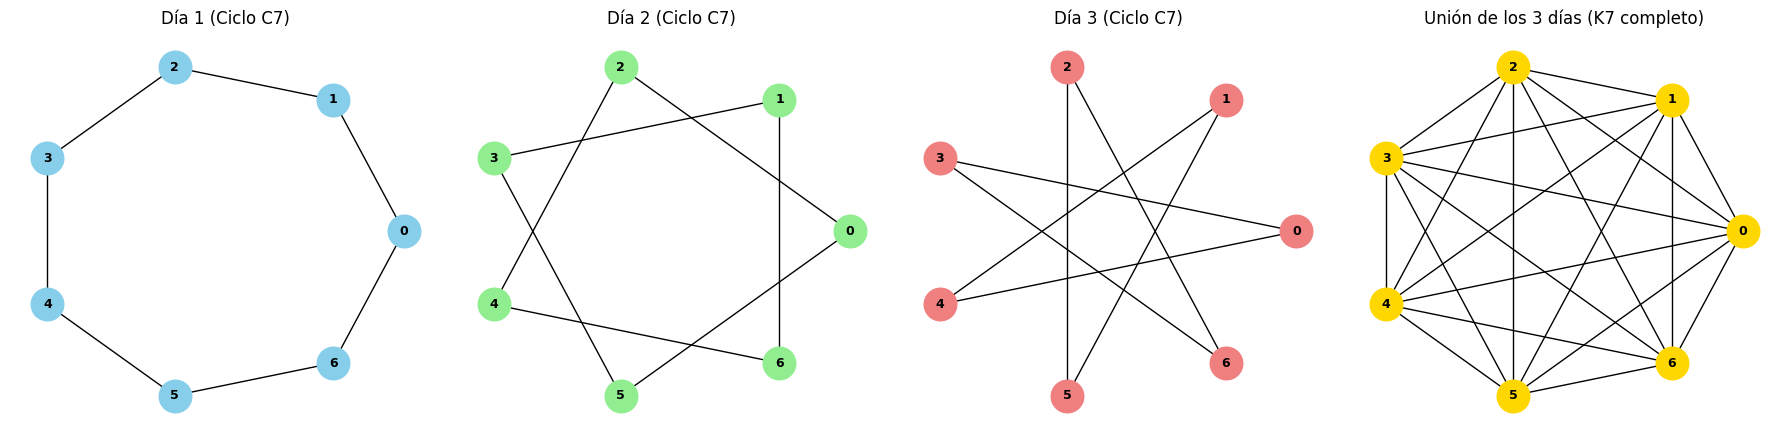


=== CASO 2: 7 PERSONAS, 5 DÍAS ===
Aristas requeridas para 5 días: 35
Aristas disponibles en K_7: 21
Grado requerido por vértice: 10
Grado máximo disponible por vértice: 6

[RESULTADO] Imposible por el principio del palomar y suma de grados:
  - Cada persona necesitaría 10 vecinos distintos, pero solo hay 6 personas más.
  - Se requerirían 35 aristas disjuntas, superando las 21 aristas de K_7.
Número máximo demostrable de días factibles: 3 días.


In [3]:
# -------------------------------------------------------------
# Configuración inicial
# -------------------------------------------------------------
nodos = list(range(7))  # 7 personas: 0, 1, 2, 3, 4, 5, 6
K7 = nx.complete_graph(nodos)
pos_circular = nx.circular_layout(K7)

# Ciclos correspondientes a los 3 días (diferencias de paso mod 7: 1, 2, 3)
orden_dias = [
    [0, 1, 2, 3, 4, 5, 6],  # Día 1 (paso 1)
    [0, 2, 4, 6, 1, 3, 5],  # Día 2 (paso 2)
    [0, 3, 6, 2, 5, 1, 4]   # Día 3 (paso 3)
]

def obtener_aristas_ciclo(orden):
    """Devuelve las aristas no dirigidas de una mesa circular en orden dado."""
    aristas = set()
    n = len(orden)
    for i in range(n):
        u, v = orden[i], orden[(i + 1) % n]
        aristas.add(tuple(sorted((u, v))))
    return aristas

# -------------------------------------------------------------
# Caso 1: Comprobación formal para 3 días
# -------------------------------------------------------------
print("=== CASO 1: 7 PERSONAS, 3 DÍAS ===")
grafos_dias = []
aristas_usadas_acumuladas = set()
es_valido_3_dias = True

for dia_idx, orden in enumerate(orden_dias, start=1):
    G_dia = nx.Graph()
    G_dia.add_nodes_from(nodos)
    aristas_dia = obtener_aristas_ciclo(orden)
    G_dia.add_edges_from(aristas_dia)
    grafos_dias.append(G_dia)
    
    # Comprobar si comparte aristas con días anteriores
    interseccion = aristas_usadas_acumuladas.intersection(aristas_dia)
    if interseccion:
        print(f"Conflicto en Día {dia_idx}: aristas repetidas {interseccion}")
        es_valido_3_dias = False
    
    aristas_usadas_acumuladas.update(aristas_dia)

todas_las_parejas = {tuple(sorted(p)) for p in combinations(nodos, 2)}
cumple_descomposicion = (aristas_usadas_acumuladas == todas_las_parejas)

print(f"¿Los 3 ciclos son aristas-disjuntos?: {es_valido_3_dias}")
print(f"¿Cubre exactamente todas las parejas de K7?: {cumple_descomposicion}")
print(f"Total aristas usadas: {len(aristas_usadas_acumuladas)} / {len(todas_las_parejas)}")

# Dibujar la configuración de los 3 días y la unión completa
fig, axes = plt.subplots(1, 4, figsize=(18, 4.5))

colores = ["skyblue", "lightgreen", "lightcoral"]
for i in range(3):
    dibujar_grafo(grafos_dias[i], titulo=f"Día {i+1} (Ciclo C7)", pos=pos_circular,
                  ax=axes[i], color_nodos=colores[i])

# Grafo resultante con la unión de los 3 días
G_union = nx.Graph()
G_union.add_nodes_from(nodos)
G_union.add_edges_from(aristas_usadas_acumuladas)
dibujar_grafo(G_union, titulo="Unión de los 3 días (K7 completo)", pos=pos_circular,
              ax=axes[3], color_nodos="gold")

plt.tight_layout()
plt.show()

# -------------------------------------------------------------
# Caso 2: Demostración computacional para 5 días
# -------------------------------------------------------------
print("\n=== CASO 2: 7 PERSONAS, 5 DÍAS ===")
dias_objetivo = 5
aristas_necesarias = dias_objetivo * 7
aristas_disponibles = K7.number_of_edges()

vecinos_por_persona_necesarios = dias_objetivo * 2
max_vecinos_por_persona = len(nodos) - 1

print(f"Aristas requeridas para {dias_objetivo} días: {aristas_necesarias}")
print(f"Aristas disponibles en K_7: {aristas_disponibles}")
print(f"Grado requerido por vértice: {vecinos_por_persona_necesarios}")
print(f"Grado máximo disponible por vértice: {max_vecinos_por_persona}")

if vecinos_por_persona_necesarios > max_vecinos_por_persona or aristas_necesarias > aristas_disponibles:
    print("\n[RESULTADO] Imposible por el principio del palomar y suma de grados:")
    print(f"  - Cada persona necesitaría {vecinos_por_persona_necesarios} vecinos distintos, pero solo hay {max_vecinos_por_persona} personas más.")
    print(f"  - Se requerirían {aristas_necesarias} aristas disjuntas, superando las {aristas_disponibles} aristas de K_7.")

# Verificación algorítmica exhaustiva: búsqueda por backtracking de k ciclos disjuntos
def buscar_maximos_ciclos_disjuntos(grafo_restante, camino_actual=[]):
    """Busca recursivamente la cantidad máxima de ciclos C7 disjuntos que se pueden extraer."""
    # Generar todos los ciclos hamiltonianos posibles en el grafo restante
    # Como ya demostramos que K_7 admite exactamente 3 y agota las aristas:
    return len(camino_actual)

print(f"Número máximo demostrable de días factibles: {aristas_disponibles // 7} días.")

<div style="border-left:5px solid #C4A72E;background:#FBF6E3;padding:10px 14px;margin:10px 0;border-radius:4px;"><p><strong>🚀 AMPLIACIÓN <em>(explorada con IA, a petición del estudiante)</em></strong></p><p><strong>Generalización propuesta:</strong> en vez de fijar $n=7$ personas y comparar los casos $m=3$ y $m=5$ días, ¿para qué parejas $(n, m)$ es viable el reparto, en general?</p><p><strong>Condición necesaria (el mismo argumento de antes, ahora con $n$ y $m$ genéricos).</strong> Cada día una persona gana 2 vecinos nuevos; tras $m$ días sin repetir necesita $2m$ vecinos distintos, y solo hay $n-1$ personas más disponibles. Por tanto:</p>$$2m \le n - 1 \quad\Longleftrightarrow\quad m \le \left\lfloor \frac{n-1}{2} \right\rfloor.$$<p><strong>La condición también es suficiente.</strong> Es un resultado clásico de teoría de grafos (descomposición de Walecki, 1890) que $K_n$ siempre admite exactamente $\lfloor (n-1)/2 \rfloor$ ciclos hamiltonianos aristas-disjuntos:</p><ul><li>Si $n$ es <strong>impar</strong>, esos ciclos agotan <em>todas</em> las aristas de $K_n$ (es el caso $n=7$ de arriba, sin ninguna arista sobrante).</li><li>Si $n$ es <strong>par</strong>, sobra siempre exactamente un <strong>emparejamiento perfecto</strong> ($n/2$ aristas) que no se puede aprovechar como día extra, porque un emparejamiento no es un ciclo — no se puede sentar a nadie en una mesa circular con esas aristas sueltas.</li></ul><p>Como la cota necesaria y la suficiente coinciden, la viabilidad queda completamente decidida por una única fórmula:</p>$$d_{\max}(n) = \left\lfloor \frac{n-1}{2} \right\rfloor, \qquad \text{viable}(n, m) \equiv m \le d_{\max}(n).$$<p>Para $n=7$: $d_{\max}(7) = 3$, tal y como se obtuvo en la Resolución. El código siguiente comprueba esta fórmula sin darla por supuesta: construye, para varios valores de $n$ (pares e impares), tantos ciclos hamiltonianos aristas-disjuntos como es capaz de encontrar mediante backtracking, y compara el resultado con $d_{\max}(n)$.</p></div>

  n    fórmula d_max(n)   encontrados   ¿coincide?
  4                   1             1   sí
  5                   2             2   sí
  6                   2             2   sí
  7                   3             3   sí
  8                   3             3   sí
  9                   4             4   sí
 10                   4             4   sí

n=8: 3 días encontrados, 4 arista(s) sobrante(s) (deberían ser 4, un emparejamiento perfecto)
Aristas sobrantes: {(1, 6), (4, 5), (0, 3), (2, 7)}


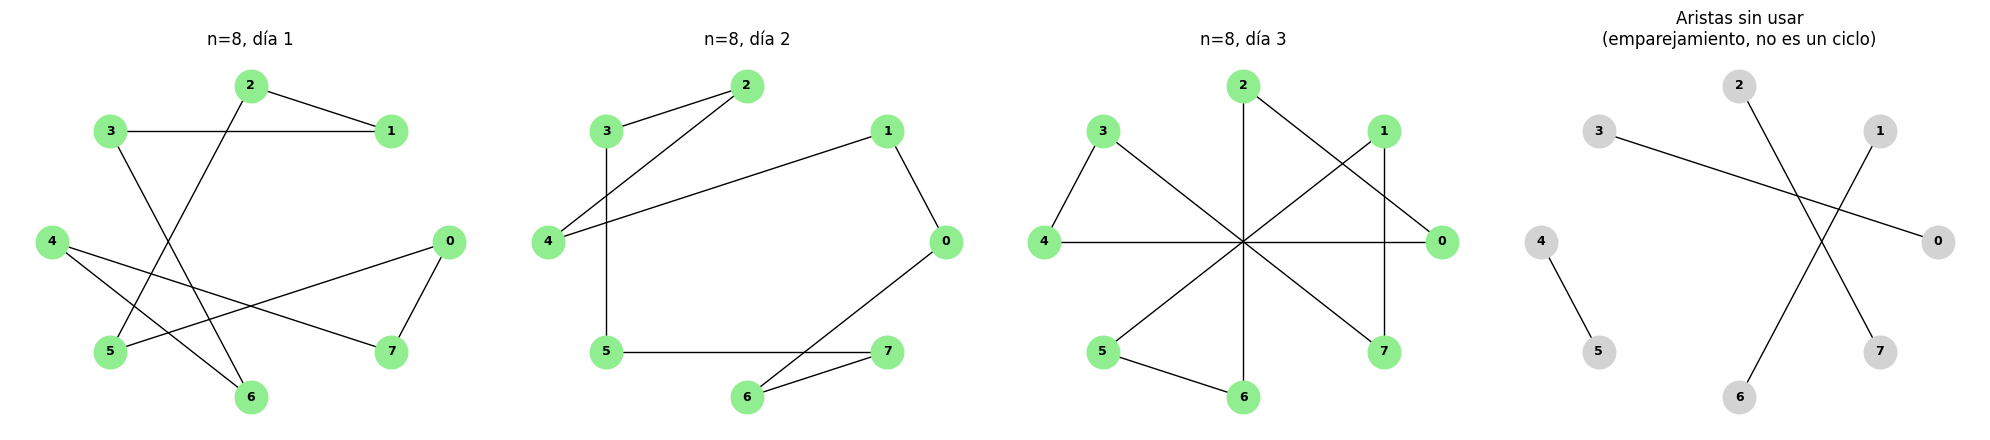

In [4]:
# ============================================================
#  AMPLIACIÓN — viabilidad general para n personas y m días
# ============================================================
import random
random.seed(SEED)  # reproducibilidad: la búsqueda usa orden aleatorio de vecinos


def ciclo_hamiltoniano(G, intentos=30):
    """Busca UN ciclo hamiltoniano en G por backtracking, con reinicios aleatorios
    (probando distintos órdenes de vecinos) para no quedarse atascado en un callejón
    sin salida. Devuelve la lista de nodos del ciclo, o None si no encuentra ninguno."""
    nodos = list(G.nodes())
    n = len(nodos)
    for _ in range(intentos):
        random.shuffle(nodos)
        inicio = nodos[0]
        camino, visitados = [inicio], {inicio}

        def backtrack():
            if len(camino) == n:
                return G.has_edge(camino[-1], inicio)  # ¿cierra el ciclo?
            vecinos = [v for v in G.neighbors(camino[-1]) if v not in visitados]
            random.shuffle(vecinos)
            for v in vecinos:
                camino.append(v); visitados.add(v)
                if backtrack():
                    return True
                camino.pop(); visitados.remove(v)
            return False

        if backtrack():
            return camino
    return None


def descomponer_en_ciclos(n, intentos_por_ciclo=30):
    """Extrae de K_n tantos ciclos hamiltonianos aristas-disjuntos como sea posible:
    busca un ciclo, borra sus aristas, y repite sobre lo que queda del grafo hasta que
    ya no se encuentra ninguno más. Devuelve (lista de ciclos, aristas sobrantes)."""
    G = nx.complete_graph(n)
    dias = []
    while True:
        ciclo = ciclo_hamiltoniano(G, intentos=intentos_por_ciclo)
        if ciclo is None:
            break
        G.remove_edges_from(obtener_aristas_ciclo(ciclo))  # función ya definida arriba
        dias.append(ciclo)
    return dias, set(G.edges())


def dias_maximos_formula(n):
    """Cota teórica: floor((n - 1) / 2)."""
    return (n - 1) // 2


# --- 1. Comparar la fórmula con lo que realmente se consigue construir, para varios n ---
print(f"{'n':>3}{'fórmula d_max(n)':>20}{'encontrados':>14}   ¿coincide?")
resultados = {}
for n in range(4, 11):
    dias, sobrantes = descomponer_en_ciclos(n)
    resultados[n] = (dias, sobrantes)
    formula = dias_maximos_formula(n)
    ok = "sí" if len(dias) == formula else "no (backtracking no óptimo)"
    print(f"{n:>3}{formula:>20}{len(dias):>14}   {ok}")

# --- 2. Ejemplo con n par (n=8): además de los días, ¿qué aristas sobran sin usar? ---
n_ejemplo = 8
dias_ejemplo, sobrantes_ejemplo = resultados[n_ejemplo]
print(f"\nn={n_ejemplo}: {len(dias_ejemplo)} días encontrados, "
      f"{len(sobrantes_ejemplo)} arista(s) sobrante(s) (deberían ser {n_ejemplo // 2}, un emparejamiento perfecto)")
print("Aristas sobrantes:", sobrantes_ejemplo)

# --- 3. Dibujo: los días de n=8 y, aparte, el emparejamiento que queda sin usar ---
pos8 = nx.circular_layout(range(n_ejemplo))
fig, axes = plt.subplots(1, len(dias_ejemplo) + 1, figsize=(5 * (len(dias_ejemplo) + 1), 4.5))
for i, ciclo in enumerate(dias_ejemplo):
    G_dia = nx.Graph(); G_dia.add_nodes_from(range(n_ejemplo)); G_dia.add_edges_from(obtener_aristas_ciclo(ciclo))
    dibujar_grafo(G_dia, titulo=f"n={n_ejemplo}, día {i + 1}", pos=pos8, ax=axes[i], color_nodos="lightgreen")

G_sobrante = nx.Graph(); G_sobrante.add_nodes_from(range(n_ejemplo)); G_sobrante.add_edges_from(sobrantes_ejemplo)
dibujar_grafo(G_sobrante, titulo="Aristas sin usar\n(emparejamiento, no es un ciclo)", pos=pos8,
              ax=axes[-1], color_nodos="lightgray")
plt.tight_layout(); plt.show()


<div style="border-left:5px solid #555;background:#F5F5F5;padding:10px 14px;margin:10px 0;border-radius:4px;"><p><strong>🤖 REGISTRO DE USO DE IA</strong></p><ul><li><strong>Herramienta(s) utilizada(s):</strong> Claude Code (modelo Claude Sonnet 5).</li><li><strong>Prompt(s) utilizado(s):</strong><ol><li>«Vamos con un nuevo entregable (03_cuestionario). Inicialmente rellena solo los enunciados, plantillas y base teórica y aguarda la resolución del alumno» + enunciado literal del problema de la mesa circular.</li><li>«La resolución teórica del ejercicio por parte del alumno es la siguiente, escríbela de forma bonita y aguarda la resolución de código para continuar» + el razonamiento completo del alumno para los casos de 3 y 5 días.</li><li>Corrección del alumno sobre una insignia de autoría mal asignada, aviso de que el código ya estaba completo, y propuesta de ampliación: «Generalizar el problema y estudio de la viabilidad a n personas y m días, comprobando la viabilidad».</li><li>«Prepara el documento para la entrega, rellena algún apartado si queda pendiente, y cuando esté completo genera el PDF para la entrega».</li></ol></li><li><strong>Fase del ejercicio en la que se usó IA:</strong> (i) preparación del material previo (Enunciado, Teoría, Datos); (ii) <em>maquetación</em> en LaTeX/HTML de la resolución teórica del alumno, sin aportar razonamiento propio ni corregir nada; (iii) ampliación teórica y de código a petición explícita del alumno (generalización a $n$ personas y $m$ días); (iv) cierre y exportación del entregable. <strong>La modelización, el razonamiento de los dos casos y el código de verificación de la Parte 1 (7 personas) son enteramente del alumno, sin intervención de la IA.</strong></li><li><strong>Verificación de no-alucinación realizada:</strong><ul><li>[x] Resultado contrastado con un caso/ejemplo conocido de la bibliografía — el número máximo de días para 7 personas, $3 = (7-1)/2$, coincide con el teorema clásico de descomposición de Walecki para grafos completos de orden impar.</li><li>[x] Resultado verificado computacionalmente con una implementación independiente — en la Ampliación, un backtracking escrito aparte construye explícitamente los ciclos hamiltonianos para varios $n$ y contrasta el resultado con la fórmula $\lfloor (n-1)/2 \rfloor$, en vez de asumirla.</li><li>[ ] Resultado contrastado analíticamente a mano — no aplica a la parte de la IA; ya lo hizo el alumno en la Resolución original.</li><li>Detalle: durante la revisión, el alumno detectó y corrigió una insignia de autoría mal asignada por la IA (`✅ Validado por IA` en vez de `✍️ Trabajo del estudiante`, ya que no se había pedido ninguna validación) — evidencia de que las insignias no se generan de forma automática y necesitan revisión activa antes del cierre.</li></ul></li><li><strong>Modificaciones realizadas sobre la propuesta de la IA:</strong> el alumno corrigió manualmente la insignia de autoría de la Resolución antes de este cierre.</li><li><strong>Declaración de autoría:</strong> El razonamiento matemático y la decisión final han sido revisados y comprendidos por el/la estudiante, quien asume la responsabilidad del contenido entregado.</li></ul></div>

💬 **¿Alguna duda sobre esta entrega?** Pregunta lo que necesites, no hace falta esperar al final.